| Message                  | Label |
| ------------------------ | ----- |
| FREE offer now           | spam  |
| WIN cash prize           | spam  |
| FREE lottery win         | spam  |
| meeting today            | ham   |
| project meeting tomorrow | ham   |
| lunch today              | ham   |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
data = {
    "message":[
        "FREE offer now",
        "WIN cash prize",
        "FREE lottery win",
        "meeting today",
        "project meeting tomorrow",
        "lunch today"
    ],
    
    "label":[
        "spam",
        "spam",
        "spam",
        "ham",
        "ham",
        "ham"
    ]
}

df = pd.DataFrame(data)

df

,message,label
0,FREE offer now,spam
1,WIN cash prize,spam
2,FREE lottery win,spam
3,meeting today,ham
4,project meeting tomorrow,ham
5,lunch today,ham


### Count words in spam and ham

In [3]:
spam_words = " ".join(df[df.label=="spam"]["message"]).lower().split()
ham_words = " ".join(df[df.label=="ham"]["message"]).lower().split()

In [5]:
print(spam_words)
print(len(spam_words))


['free', 'offer', 'now', 'win', 'cash', 'prize', 'free', 'lottery', 'win']
9


In [6]:
print(ham_words)
print(len(ham_words))


['meeting', 'today', 'project', 'meeting', 'tomorrow', 'lunch', 'today']
7


In [7]:
spam_counts = Counter(spam_words)
ham_counts = Counter(ham_words)

print("Spam word counts:", spam_counts)
print("Ham word counts:", ham_counts)

Spam word counts: Counter({'free': 2, 'win': 2, 'offer': 1, 'now': 1, 'cash': 1, 'prize': 1, 'lottery': 1})
Ham word counts: Counter({'meeting': 2, 'today': 2, 'project': 1, 'tomorrow': 1, 'lunch': 1})


### Visualize Word Frequencies

In [15]:
spam_series = pd.Series(spam_counts)
ham_series = pd.Series(ham_counts)

In [16]:
spam_series

free       2
offer      1
now        1
win        2
cash       1
prize      1
lottery    1
dtype: int64

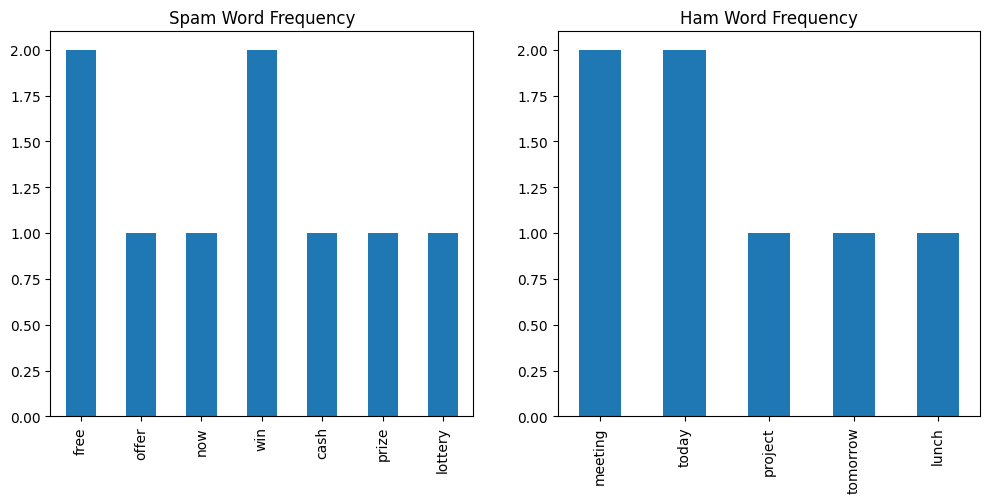

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
spam_series.plot(kind="bar")
plt.title("Spam Word Frequency")

plt.subplot(1,2,2)
ham_series.plot(kind="bar")
plt.title("Ham Word Frequency")

plt.show()

<Axes: >

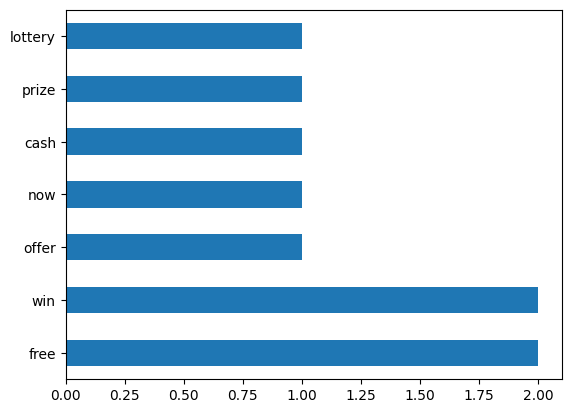

In [20]:
pd.Series(spam_words).value_counts().plot(kind="barh")

### Prior Probabilities

Naive Bayes first calculates prior probability.

- P(spam)=
3/6=0.5
- P(ham)=
3/6=0.5

In [21]:
p_spam = len(df[df.label=="spam"]) / len(df)
p_ham = len(df[df.label=="ham"]) / len(df)

print("P(spam):",p_spam)
print("P(ham):",p_ham)

P(spam): 0.5
P(ham): 0.5


### Word Probabilities

Calculate probability of FREE and WIN.

Example:

P(FREE∣spam)

In [22]:
total_spam_words = len(spam_words)
total_spam_words

9

In [23]:

p_free_spam = spam_counts["free"] / total_spam_words
p_win_spam = spam_counts["win"] / total_spam_words

print("P(FREE|spam)",p_free_spam)
print("P(WIN|spam)",p_win_spam)

P(FREE|spam) 0.2222222222222222
P(WIN|spam) 0.2222222222222222


### Final Spam Probability
Naive Bayes formula:

    - P(spam∣message)

In [25]:
spam_probability = p_spam * p_free_spam * p_win_spam
print("Spam score:",spam_probability)

Spam score: 0.024691358024691357


In [26]:
p_free_ham = ham_counts.get("free",0) / len(ham_words)
p_win_ham = ham_counts.get("win",0) / len(ham_words)

ham_probability = p_ham * p_free_ham * p_win_ham

print("Ham score:",ham_probability)

Ham score: 0.0


In [33]:
# Final Prediction
if spam_probability > ham_probability:
    print("Message classified as SPAM")
else:
    print("Message classified as HAM")

Message classified as SPAM


In [37]:
# Priors
P_spam = 0.5
P_ham = 0.5

# Word likelihoods
P_free_spam = 0.33
P_win_spam = 0.33
P_free_ham = 0.01
P_win_ham = 0.01

# Bayes expansion
spam_score = P_spam * P_free_spam * P_win_spam
ham_score = P_ham * P_free_ham * P_win_ham

print("Spam score =", P_spam, "*", P_free_spam, "*", P_win_spam, "=", spam_score)
print("Ham score =", P_ham, "*", P_free_ham, "*", P_win_ham, "=", ham_score)

print("Prediction:", "SPAM" if spam_score > ham_score else "HAM")

Spam score = 0.5 * 0.33 * 0.33 = 0.054450000000000005
Ham score = 0.5 * 0.01 * 0.01 = 5e-05
Prediction: SPAM


## Interesting things about Naive Bayes

### 1. It Works Even When the Assumption Is Wrong
- Naive Bayes assumes all features are independent.
- Example:

FREE and WIN are independent

- But in real life they are **not independent**.

- Still the algorithm works **surprisingly well**.

**`Naive Bayes is called “naive” because it makes unrealistic assumptions but still performs amazingly well.`**

### 2. It Works With Very Small Data
- Most ML algorithms need lots of data, but Naive Bayes can work with very few samples.

- Example:

    - You can train spam detection with just a few messages.

**`Naive Bayes learns probabilities instead of complex patterns.`**

### 3. It Is Extremely Fast
- Naive Bayes is one of the fastest ML algorithms.

- Training time is very small because it only calculates **probabilities and word counts**.

Good for:

    - email filtering
    - news classification
    - real-time text systems

### 4. It Works Very Well For Text Data

### 5. It Can Work With Very High Dimensions
- Text data may have thousands of words.

- Most algorithms struggle with this.

- But Naive Bayes handles it easily.

Example:

**`Vocabulary size = 50,000 words`**

Naive Bayes still works smoothly.

### 6. It Can Predict Even If It Has Never Seen the Exact Sentence
- Example training data:

    1. FREE offer now
    2. WIN cash prize
- New message:

    1. FREE cash now

Even if the **exact sentence never appeared**, Naive Bayes can still classify it.

Because it looks at word probabilities individually.

### 7. The Model Is Very Easy to Interpret

- Unlike many ML models, Naive Bayes is transparent.

You can easily see:

    - Which words make a message spam

Example:

    1. FREE → high spam probability
    2. meeting → high ham probability

Students can **inspect the probabilities directly**.